Resume Screening

In [ ]:
!pip install pdfplumber
!pip install PyPDF2
!pip install python-docx
!pip install nltk
!pip install spacy
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
import os

# NLP Libraries
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# PDF Reading
import pdfplumber
import PyPDF2

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# WordCloud
from wordcloud import WordCloud

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
!mkdir resumes
!mkdir job_description
!mkdir output

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Rani_Backend_Resume.pdf to Rani_Backend_Resume.pdf


In [ ]:
import shutil

for file_name in uploaded.keys():
    shutil.move(file_name, f"resumes/{file_name}")

print("Files moved successfully")

Files moved successfully


In [ ]:
os.listdir("resumes")

['Rani_Backend_Resume.pdf']

In [ ]:
def extract_text_from_pdf(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:

        for page in pdf.pages:

            extracted = page.extract_text()

            if extracted:
                text += extracted

    return text

In [ ]:
resume_path = "resumes/" + os.listdir("resumes")[0]

resume_text = extract_text_from_pdf(resume_path)

print(resume_text[:3000])

RANI MARAPAKA
Backend Developer
+91-6304034171 | ✉ marapakarani@gmail.com| Hyderabad, India |https://github.com/Marapaka12 |
https://www.linkedin.com/in/rani-marapaka-714957218
Professional summary
Motivated and detail-oriented Backend Developer with strong knowledge of Python, Flask, SQL, and REST
API development. Passionate about building scalable, secure, and efficient server-side systems. Seeking an
opportunity to apply backend and database design skills in a dynamic development team.
Technical Skills
• Programming Languages: Python, JavaScript, SQL
• Frameworks: Flask, Django
• Database Management: MySQL, PostgreSQL
• API Development: RESTful APIs, Postman
• Tools & Version Control: Git, GitHub
• Cloud & File Handling: AWS (basic), Cloud Storage, Image Uploads
Projects
Integrated Coding Development Platform for Collegiate Students
• Flask | PostgreSQL | JWT Authentication | File Handling
• Developed a web-based platform for college students to write, run, and submit coding assignm

In [ ]:
resume_path = "resumes/" + os.listdir("resumes")[0]

resume_text = extract_text_from_pdf(resume_path)

print(resume_text[:3000])

RANI MARAPAKA
Backend Developer
+91-6304034171 | ✉ marapakarani@gmail.com| Hyderabad, India |https://github.com/Marapaka12 |
https://www.linkedin.com/in/rani-marapaka-714957218
Professional summary
Motivated and detail-oriented Backend Developer with strong knowledge of Python, Flask, SQL, and REST
API development. Passionate about building scalable, secure, and efficient server-side systems. Seeking an
opportunity to apply backend and database design skills in a dynamic development team.
Technical Skills
• Programming Languages: Python, JavaScript, SQL
• Frameworks: Flask, Django
• Database Management: MySQL, PostgreSQL
• API Development: RESTful APIs, Postman
• Tools & Version Control: Git, GitHub
• Cloud & File Handling: AWS (basic), Cloud Storage, Image Uploads
Projects
Integrated Coding Development Platform for Collegiate Students
• Flask | PostgreSQL | JWT Authentication | File Handling
• Developed a web-based platform for college students to write, run, and submit coding assignm

Preprocessing

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['until', 'those', 'couldn', 'm', 'be', "couldn't", 'needn', 'we', 'him', 'of', 'its', 'the', 'yours', 'is', 'their', 'they', 'himself', "isn't", "hasn't", "we'll"]


In [ ]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    filtered_tokens = []

    for word in tokens:
        if word not in stop_words:
            filtered_tokens.append(word)

    # Join words again
    cleaned_text = " ".join(filtered_tokens)

    return cleaned_text

In [ ]:
cleaned_resume = preprocess_text(resume_text)

print(cleaned_resume[:3000])

rani marapaka backend developer hyderabad india professional summary motivated detailoriented backend developer strong knowledge python flask sql rest api development passionate building scalable secure efficient serverside systems seeking opportunity apply backend database design skills dynamic development team technical skills programming languages python javascript sql frameworks flask django database management mysql postgresql api development restful apis postman tools version control git github cloud file handling aws basic cloud storage image uploads projects integrated coding development platform collegiate students flask postgresql jwt authentication file handling developed webbased platform college students write run submit coding assignments designed implemented restful apis user registration login code submission result fetching created robust database schema users assignments submissions scores integrated jwt authentication secure access rolebased functionality student ins

In [ ]:
tokens = word_tokenize(cleaned_resume)

print(tokens[:50])

['rani', 'marapaka', 'backend', 'developer', 'hyderabad', 'india', 'professional', 'summary', 'motivated', 'detailoriented', 'backend', 'developer', 'strong', 'knowledge', 'python', 'flask', 'sql', 'rest', 'api', 'development', 'passionate', 'building', 'scalable', 'secure', 'efficient', 'serverside', 'systems', 'seeking', 'opportunity', 'apply', 'backend', 'database', 'design', 'skills', 'dynamic', 'development', 'team', 'technical', 'skills', 'programming', 'languages', 'python', 'javascript', 'sql', 'frameworks', 'flask', 'django', 'database', 'management', 'mysql']


In [ ]:
print("Total Words:", len(tokens))

Total Words: 205


In [ ]:
from collections import Counter

word_freq = Counter(tokens)

print(word_freq.most_common(20))

[('backend', 6), ('development', 6), ('python', 4), ('flask', 4), ('api', 4), ('database', 4), ('skills', 4), ('file', 4), ('secure', 3), ('apis', 3), ('handling', 3), ('coding', 3), ('authentication', 3), ('assignments', 3), ('certification', 3), ('rani', 2), ('marapaka', 2), ('developer', 2), ('hyderabad', 2), ('strong', 2)]


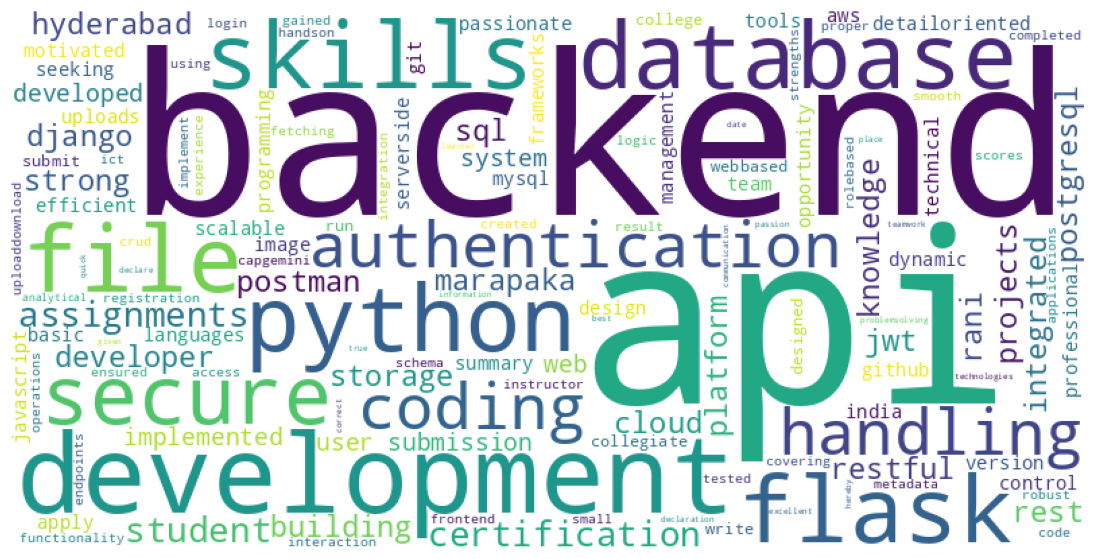

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(cleaned_resume)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

Lemmatization

In [ ]:
def lemmatize_text(text):

    doc = nlp(text)

    lemmas = []

    for token in doc:
        lemmas.append(token.lemma_)

    return " ".join(lemmas)

In [ ]:
lemmatized_resume = lemmatize_text(cleaned_resume)

print(lemmatized_resume[:3000])

rani marapaka backend developer hyderabad india professional summary motivate detailoriente backend developer strong knowledge python flask sql rest api development passionate build scalable secure efficient serverside system seek opportunity apply backend database design skill dynamic development team technical skill programming language python javascript sql frameworks flask django database management mysql postgresql api development restful apis postman tool version control git github cloud file handle aw basic cloud storage image upload project integrate cod development platform collegiate student flask postgresql jwt authentication file handling develop webbase platform college student write run submit cod assignment design implement restful apis user registration login code submission result fetch create robust database schema user assignment submission score integrate jwt authentication secure access rolebase functionality student instructor implement file uploaddownload system 

In [ ]:
with open("output/processed_resume.txt", "w") as file:

    file.write(lemmatized_resume)

print("Processed resume saved successfully")

Processed resume saved successfully


In [ ]:
processed_resumes = {}

for file_name in os.listdir("resumes"):

    path = os.path.join("resumes", file_name)

    text = extract_text_from_pdf(path)

    cleaned = preprocess_text(text)

    lemmatized = lemmatize_text(cleaned)

    processed_resumes[file_name] = lemmatized

print("Total resumes processed:", len(processed_resumes))

Total resumes processed: 1


In [ ]:
for name, content in processed_resumes.items():

    print("Resume:", name)

    print(content[:1000])

    print("\n")

Resume: Rani_Backend_Resume.pdf
rani marapaka backend developer hyderabad india professional summary motivate detailoriente backend developer strong knowledge python flask sql rest api development passionate build scalable secure efficient serverside system seek opportunity apply backend database design skill dynamic development team technical skill programming language python javascript sql frameworks flask django database management mysql postgresql api development restful apis postman tool version control git github cloud file handle aw basic cloud storage image upload project integrate cod development platform collegiate student flask postgresql jwt authentication file handling develop webbase platform college student write run submit cod assignment design implement restful apis user registration login code submission result fetch create robust database schema user assignment submission score integrate jwt authentication secure access rolebase functionality student instructor imple

In [ ]:
job_description = """
We are looking for a Data Scientist with skills in:

Python
Machine Learning
Deep Learning
NLP
SQL
TensorFlow
Data Analysis
Flask
Scikit-learn

Experience in AI projects is preferred.
"""

In [ ]:
cleaned_job_description = preprocess_text(job_description)

lemmatized_job_description = lemmatize_text(
    cleaned_job_description
)

print(lemmatized_job_description)

look datum scientist skill python machine learn deep learning nlp sql tensorflow datum analysis flask scikitlearn experience ai project prefer


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
documents = [
    lemmatized_resume,
    lemmatized_job_description
]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [ ]:
similarity_score = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)

score = similarity_score[0][0] * 100

print(f"Resume Match Score: {score:.2f}%")

Resume Match Score: 9.78%


In [ ]:
resume_scores = {}

for file_name, resume_content in processed_resumes.items():

    documents = [
        resume_content,
        lemmatized_job_description
    ]

    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(documents)

    similarity = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )

    score = similarity[0][0] * 100

    resume_scores[file_name] = score

In [ ]:
resume_scores

{'Rani_Backend_Resume.pdf': np.float64(9.778763137221299)}

In [ ]:
ranked_resumes = sorted(
    resume_scores.items(),
    key=lambda x: x[1],
    reverse=True
)

In [ ]:
print("===== Candidate Ranking =====\n")

rank = 1

for resume, score in ranked_resumes:

    print(f"Rank #{rank}")

    print(f"Resume: {resume}")

    print(f"Match Score: {score:.2f}%")

    print("------------------------")

    rank += 1

===== Candidate Ranking =====

Rank #1
Resume: Rani_Backend_Resume.pdf
Match Score: 9.78%
------------------------


In [ ]:
results_df = pd.DataFrame(
    ranked_resumes,
    columns=["Resume", "Score"]
)

results_df

,Resume,Score
0,Rani_Backend_Resume.pdf,9.778763


/tmp/ipykernel_1871/2196720655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


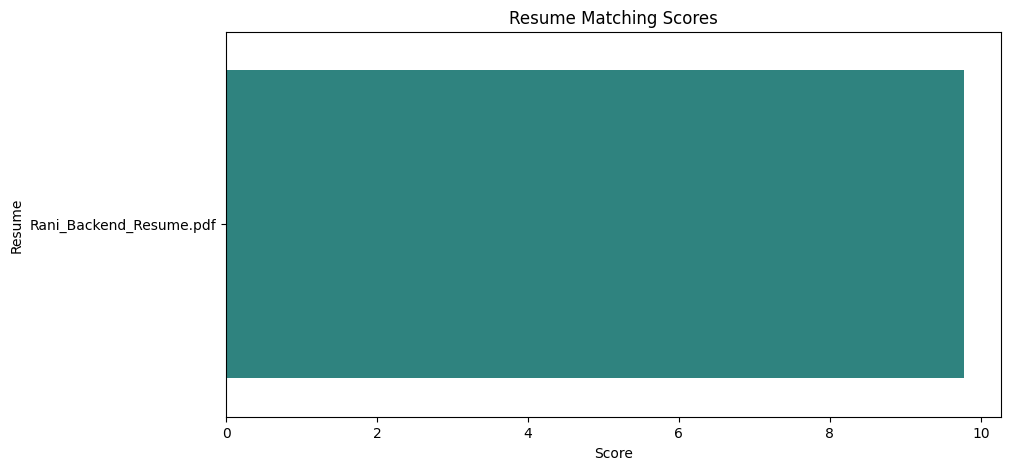

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Score",
    y="Resume",
    data=results_df,
    palette="viridis"
)

plt.title("Resume Matching Scores")

plt.xlabel("Score")

plt.ylabel("Resume")

plt.show()

In [ ]:
results_df.to_csv(
    "output/resume_ranking_results.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully


In [ ]:
from google.colab import files

files.download(
    "output/resume_ranking_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UpdatedResumeDataSet.csv to UpdatedResumeDataSet.csv


In [ ]:
dataset = pd.read_csv("UpdatedResumeDataSet.csv")

dataset.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
dataset.shape

(962, 2)

View Job Categories

In [ ]:
dataset['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [ ]:
dataset['Cleaned_Resume'] = dataset['Resume'].apply(
    preprocess_text
)

In [ ]:
#Lemmatize
dataset['Cleaned_Resume'] = dataset[
    'Cleaned_Resume'
].apply(lemmatize_text)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

dataset['Category_Encoded'] = encoder.fit_transform(
    dataset['Category']
)

In [ ]:
dataset[['Category', 'Category_Encoded']].head()

,Category,Category_Encoded
0,Data Science,6
1,Data Science,6
2,Data Science,6
3,Data Science,6
4,Data Science,6


Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = dataset['Cleaned_Resume']

y = dataset['Category_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Creating PipeLine

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('classifier', MultinomialNB())])

Testing Accuracy

In [ ]:
accuracy = model.score(X_test, y_test)

print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 96.89%


In [ ]:
predicted_label = model.predict([lemmatized_resume])[0]

predicted_category = encoder.inverse_transform(
    [predicted_label]
)[0]

print("Predicted Job Role:")
print(predicted_category)

Predicted Job Role:
Java Developer


In [ ]:
predictions = {}

for file_name, content in processed_resumes.items():

    label = model.predict([content])[0]

    category = encoder.inverse_transform([label])[0]

    predictions[file_name] = category

predictions

{'Rani_Backend_Resume.pdf': 'Java Developer'}

In [ ]:
print(" Resume Role Predictions \n")

for resume, role in predictions.items():

    print(f"Resume: {resume}")

    print(f"Predicted Role: {role}")

 Resume Role Predictions 

Resume: Rani_Backend_Resume.pdf
Predicted Role: Java Developer


Classification Report

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      0.80      0.89         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      0.92      0.96        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       0.75      1.00      0.86        15
          16       1.00      1.00      1.00         8
          17       1.00    

In [ ]:
import pickle

with open("output/resume_classifier.pkl", "wb") as file:

    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [ ]:
with open("output/resume_classifier.pkl", "rb") as file:

    loaded_model = pickle.load(file)

In [ ]:
skills_database = [
    "python",
    "java",
    "c++",
    "sql",
    "mysql",
    "mongodb",
    "machine learning",
    "deep learning",
    "nlp",
    "tensorflow",
    "keras",
    "pytorch",
    "data science",
    "flask",
    "django",
    "html",
    "css",
    "javascript",
    "react",
    "nodejs",
    "aws",
    "docker",
    "kubernetes",
    "git",
    "power bi",
    "excel"
]

In [ ]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills_database:

        if skill in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [ ]:
resume_skills = extract_skills(lemmatized_resume)

print("Extracted Skills:")
print(resume_skills)

Extracted Skills:
['python', 'django', 'javascript', 'git', 'mysql', 'java', 'excel', 'flask', 'sql']


In [ ]:
resume_skill_results = {}

for file_name, content in processed_resumes.items():

    skills = extract_skills(content)

    resume_skill_results[file_name] = skills

In [ ]:
print("Resume Skills \n")

for resume, skills in resume_skill_results.items():

    print(f"Resume: {resume}")

    print(f"Skills: {skills}")

Resume Skills 

Resume: Rani_Backend_Resume.pdf
Skills: ['python', 'django', 'javascript', 'git', 'mysql', 'java', 'excel', 'flask', 'sql']


In [ ]:
job_skills = extract_skills(
    lemmatized_job_description
)

print(job_skills)

['python', 'deep learning', 'nlp', 'flask', 'sql', 'tensorflow']


In [ ]:
def calculate_skill_match(
    resume_skills,
    job_skills
):

    matched = set(resume_skills).intersection(
        set(job_skills)
    )

    match_percentage = (
        len(matched) / len(job_skills)
    ) * 100

    return matched, match_percentage

In [ ]:
matched_skills, percentage = calculate_skill_match(
    resume_skills,
    job_skills
)

print("Matched Skills:")
print(matched_skills)

print(f"\nSkill Match Percentage: {percentage:.2f}%")

Matched Skills:
{'python', 'flask', 'sql'}

Skill Match Percentage: 50.00%


In [ ]:
all_skill_matches = {}

for resume, skills in resume_skill_results.items():

    matched, percentage = calculate_skill_match(
        skills,
        job_skills
    )

    all_skill_matches[resume] = {
        "matched_skills": matched,
        "percentage": percentage
    }

In [ ]:
print("Skill Match Results \n")

for resume, result in all_skill_matches.items():

    print(f"Resume: {resume}")

    print(f"Matched Skills: {result['matched_skills']}")

    print(f"Skill Match: {result['percentage']:.2f}%")


Skill Match Results 

Resume: Rani_Backend_Resume.pdf
Matched Skills: {'python', 'flask', 'sql'}
Skill Match: 50.00%


In [ ]:
skill_data = []

for resume, result in all_skill_matches.items():

    skill_data.append([
        resume,
        list(result['matched_skills']),
        result['percentage']
    ])

skill_df = pd.DataFrame(
    skill_data,
    columns=[
        "Resume",
        "Matched Skills",
        "Skill Match %"
    ]
)

skill_df

,Resume,Matched Skills,Skill Match %
0,Rani_Backend_Resume.pdf,"[python, flask, sql]",50.0


/tmp/ipykernel_1871/3168701480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


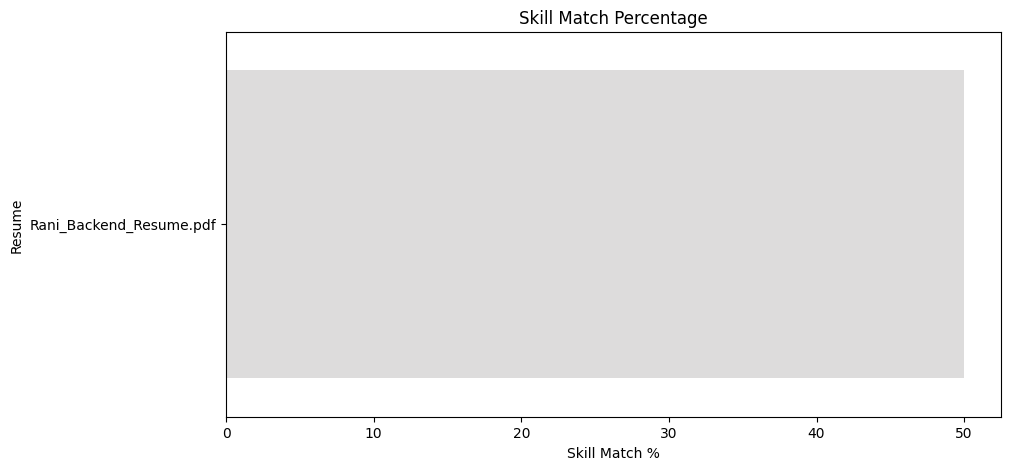

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Skill Match %",
    y="Resume",
    data=skill_df,
    palette="coolwarm"
)

plt.title("Skill Match Percentage")

plt.show()

In [ ]:
skill_df.to_csv(
    "output/skill_match_results.csv",
    index=False
)

print("Skill results saved")

Skill results saved
